# Week 5 Assignment — Text Generation with RNN, LSTM & GRU

**Name:** Sahil Yadav

**Objective:** Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using vanilla RNN, LSTM, and GRU.

---

## Problem Statement

Build and compare 3 recurrent models for next-word prediction:
1. Vanilla RNN
2. LSTM
3. GRU

Train all three on same corpus, compare loss/accuracy, and generate text from each.

## 1. Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0


GPU available: False


## 2. Text Corpus

Using a small corpus so it runs fast. Can replace with shakespeare or anything bigger later.

In [2]:
corpus = """
deep learning is transforming the field of artificial intelligence
neural networks can learn complex patterns from large amounts of data
recurrent neural networks are designed to handle sequential data
the hidden state in a recurrent network carries information across time steps
long short term memory networks solve the vanishing gradient problem
lstm uses three gates called input gate forget gate and output gate
the forget gate decides what information to discard from the cell state
the input gate controls which new values update the cell state
the output gate determines the next hidden state value
gated recurrent units combine the forget and input gates into a single update gate
gru is computationally more efficient than lstm with similar performance
text generation models learn to predict the next word in a sequence
language models assign probabilities to sequences of words
training a language model requires a large text corpus and sufficient compute
natural language processing has many applications like translation and summarization
word embeddings capture semantic relationships between words in vector space
the embedding layer maps each word to a dense vector representation
sequence to sequence models are used for machine translation tasks
attention mechanisms allow models to focus on relevant parts of the input
transformers have largely replaced recurrent networks in modern nlp systems
deep learning models require careful tuning of hyperparameters for best results
dropout is a regularization technique that prevents overfitting in neural networks
batch normalization helps stabilize and accelerate the training process
gradient descent optimizes model parameters by minimizing the loss function
adam optimizer combines momentum and adaptive learning rate for faster convergence
the softmax function converts raw outputs into probability distributions over classes
cross entropy loss measures how well predicted probabilities match true labels
backpropagation through time extends backpropagation for recurrent neural networks
vanishing gradients make it difficult for vanilla rnns to learn long range dependencies
exploding gradients can be controlled using gradient clipping techniques
"""

# quick look at what we have
lines = [l.strip() for l in corpus.strip().split('\n') if l.strip()]
print(f'Number of lines in corpus: {len(lines)}')
print(f'Total characters: {len(corpus)}')
print(f'\nFirst 3 lines:')
for l in lines[:3]:
    print(f'  -> {l}')

Number of lines in corpus: 30
Total characters: 2219

First 3 lines:
  -> deep learning is transforming the field of artificial intelligence
  -> neural networks can learn complex patterns from large amounts of data
  -> recurrent neural networks are designed to handle sequential data


## 3. Tokenization & Sequences

Convert text to tokens, create n-gram sequences, pad them, split into X and y.

In [3]:
# tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1  # +1 for padding index 0
print(f'Vocabulary size: {total_words}')

# check a few word -> index mappings
sample_words = ['the', 'learning', 'lstm', 'gradient', 'networks']
for w in sample_words:
    if w in tokenizer.word_index:
        print(f'  "{w}" -> {tokenizer.word_index[w]}')

Vocabulary size: 202
  "the" -> 1
  "learning" -> 15
  "lstm" -> 34
  "gradient" -> 18
  "networks" -> 5


In [4]:
# create n-gram sequences
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

# pad sequences so they're all the same length
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

print(f'Total sequences created: {len(input_sequences)}')
print(f'Max sequence length: {max_len}')

# show a couple examples to make sure it looks right
print(f'\nExample padded sequence: {input_sequences[0]}')
print(f'Example padded sequence: {input_sequences[5]}')

Total sequences created: 289
Max sequence length: 14

Example padded sequence: [ 0  0  0  0  0  0  0  0  0  0  0  0 23 15]
Example padded sequence: [ 0  0  0  0  0  0  0 23 15 16 52  1 53  7]


In [5]:
# features = all tokens except last, label = last token
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f'X shape: {X.shape}')   # (num_sequences, max_len-1)
print(f'y shape: {y.shape}')   # (num_sequences,)
print(f'\nSample X[0]: {X[0]}')
print(f'Sample y[0]: {y[0]}')  # the word index we're trying to predict

X shape: (289, 13)
y shape: (289,)

Sample X[0]: [ 0  0  0  0  0  0  0  0  0  0  0  0 23]
Sample y[0]: 15


## 4. Model Builder

Same architecture for all 3 — just swapping the recurrent layer. Keeping everything else same so comparison is fair.

In [6]:
EMBED_DIM = 64
RNN_UNITS = 128
DROPOUT_RATE = 0.2
EPOCHS = 100
INPUT_LEN = max_len - 1

def build_model(rnn_type='SimpleRNN'):
    """Build a text generation model with the specified recurrent layer."""
    model = Sequential()
    model.add(Embedding(total_words, EMBED_DIM, input_length=INPUT_LEN))
    
    if rnn_type == 'SimpleRNN':
        model.add(SimpleRNN(RNN_UNITS))
    elif rnn_type == 'LSTM':
        model.add(LSTM(RNN_UNITS))
    elif rnn_type == 'GRU':
        model.add(GRU(RNN_UNITS))
    else:
        raise ValueError(f'Unknown rnn_type: {rnn_type}')
    
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(total_words, activation='softmax'))
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

print('Model builder ready')

Model builder ready


## 5. Vanilla RNN

In [7]:
rnn_model = build_model('SimpleRNN')
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
print('Training Vanilla RNN...')
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nVanilla RNN training done!')
print(f'Final loss: {rnn_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {rnn_history.history["accuracy"][-1]:.4f}')

Training Vanilla RNN...


Epoch 1/100


 1/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.0000e+00 - loss: 5.3296

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 8.1983e-04 - loss: 5.3167

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0035 - loss: 5.3116   


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9792 - loss: 0.1732 


Epoch 100/100


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0839

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9758 - loss: 0.1727 



Vanilla RNN training done!
Final loss: 0.1727
Final accuracy: 0.9758


## 6. LSTM

In [9]:
lstm_model = build_model('LSTM')
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
print('Training LSTM...')
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nLSTM training done!')
print(f'Final loss: {lstm_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {lstm_history.history["accuracy"][-1]:.4f}')

Training LSTM...
Epoch 1/100


 1/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.0625 - loss: 5.3083

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0368 - loss: 5.3084

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0242 - loss: 5.3098


Epoch 2/100


...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9375 - loss: 0.7914

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8776 - loss: 0.8336 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8374 - loss: 0.8900



LSTM training done!


Final loss: 0.8900
Final accuracy: 0.8374


## 7. GRU

In [11]:
gru_model = build_model('GRU')
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
print('Training GRU...')
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=1)
print('\nGRU training done!')
print(f'Final loss: {gru_history.history["loss"][-1]:.4f}')
print(f'Final accuracy: {gru_history.history["accuracy"][-1]:.4f}')

Training GRU...


Epoch 1/100


 1/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.0000e+00 - loss: 5.3083

 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0023 - loss: 5.3080    

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0035 - loss: 5.3077


...

Epoch 100/100


 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9688 - loss: 0.2366

 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9745 - loss: 0.2139 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9689 - loss: 0.2170



GRU training done!
Final loss: 0.2170
Final accuracy: 0.9689


## 8. Loss & Accuracy Plots

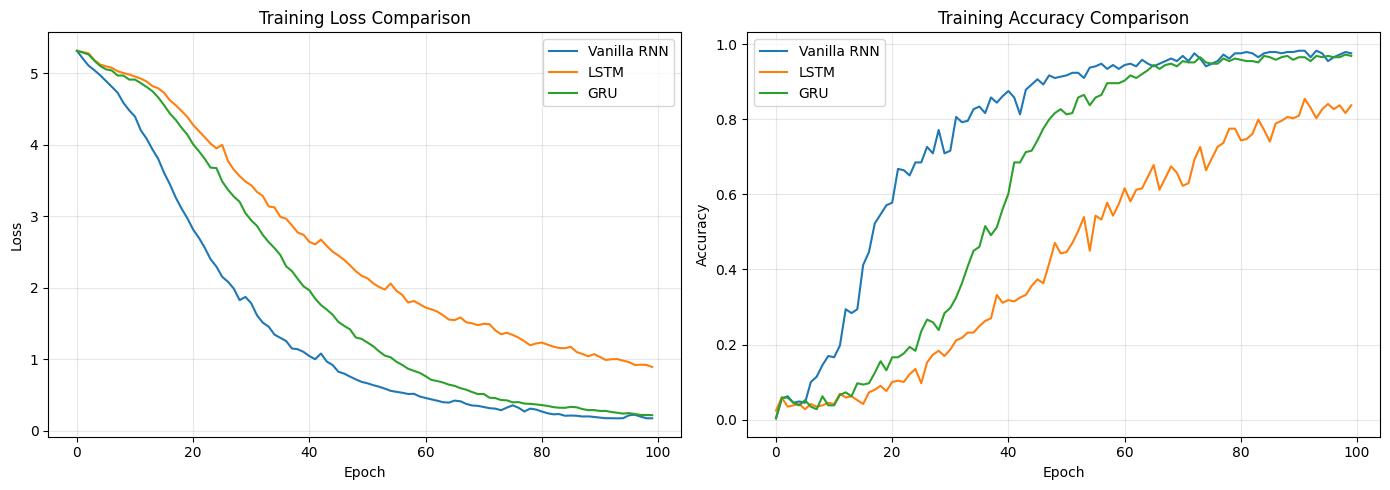

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss comparison
axes[0].plot(rnn_history.history['loss'], label='Vanilla RNN', linewidth=1.5)
axes[0].plot(lstm_history.history['loss'], label='LSTM', linewidth=1.5)
axes[0].plot(gru_history.history['loss'], label='GRU', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# accuracy comparison
axes[1].plot(rnn_history.history['accuracy'], label='Vanilla RNN', linewidth=1.5)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM', linewidth=1.5)
axes[1].plot(gru_history.history['accuracy'], label='GRU', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# print a summary table so it's easy to compare
print(f'{"Model":<15} {"Final Loss":<15} {"Final Accuracy":<15}')
print('-' * 45)
print(f'{"Vanilla RNN":<15} {rnn_history.history["loss"][-1]:<15.4f} {rnn_history.history["accuracy"][-1]:<15.4f}')
print(f'{"LSTM":<15} {lstm_history.history["loss"][-1]:<15.4f} {lstm_history.history["accuracy"][-1]:<15.4f}')
print(f'{"GRU":<15} {gru_history.history["loss"][-1]:<15.4f} {gru_history.history["accuracy"][-1]:<15.4f}')

Model           Final Loss      Final Accuracy 
---------------------------------------------
Vanilla RNN     0.1727          0.9758         
LSTM            0.8900          0.8374         
GRU             0.2170          0.9689         


### Parameter Count

Vanilla RNN parameters: 63,690
LSTM parameters:        137,802
GRU parameters:         113,482


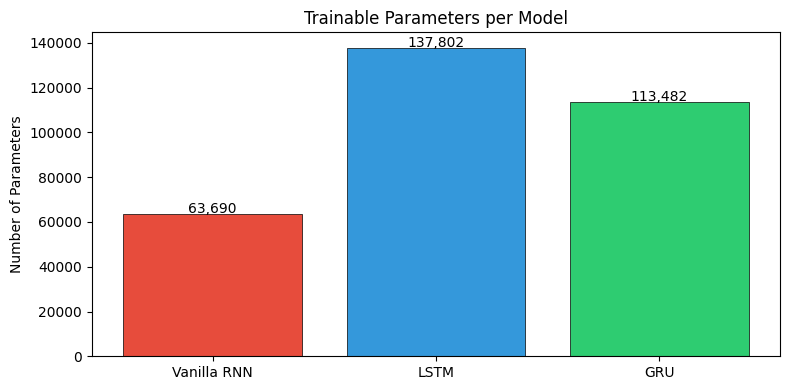

In [15]:
rnn_params  = rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params  = gru_model.count_params()

print(f'Vanilla RNN parameters: {rnn_params:,}')
print(f'LSTM parameters:        {lstm_params:,}')
print(f'GRU parameters:         {gru_params:,}')

# bar chart for visual comparison
models = ['Vanilla RNN', 'LSTM', 'GRU']
params = [rnn_params, lstm_params, gru_params]
colors = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 4))
bars = plt.bar(models, params, color=colors, edgecolor='black', linewidth=0.5)
for bar, p in zip(bars, params):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{p:,}', ha='center', fontsize=10)
plt.ylabel('Number of Parameters')
plt.title('Trainable Parameters per Model')
plt.tight_layout()
plt.show()

## 9. Text Generation

In [16]:
def generate_text(model, seed_text, next_words=10):
    """Generate text by predicting next word iteratively."""
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)
        
        # find the word for this index
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        result += ' ' + output_word
    return result

print('Text generation function ready')

Text generation function ready


In [17]:
# try a few different seed phrases
seed_phrases = ['deep learning', 'neural networks', 'the model', 'gradient descent']

print('='*70)
print('TEXT GENERATION RESULTS (Greedy / Argmax)')
print('='*70)

for seed in seed_phrases:
    print(f'\nSeed: "{seed}"')
    print(f'  RNN  : {generate_text(rnn_model, seed, 8)}')
    print(f'  LSTM : {generate_text(lstm_model, seed, 8)}')
    print(f'  GRU  : {generate_text(gru_model, seed, 8)}')

TEXT GENERATION RESULTS (Greedy / Argmax)

Seed: "deep learning"


  RNN  : deep learning models require careful tuning of hyperparameters for best


  LSTM : deep learning models require careful tuning of hyperparameters for best


  GRU  : deep learning models require careful tuning of hyperparameters for best

Seed: "neural networks"


  RNN  : neural networks can learn complex patterns from large amounts of


...

  LSTM : the model function converts raw outputs into probability distributions distributions


  GRU  : the model gate decides what information to discard from the

Seed: "gradient descent"


  RNN  : gradient descent optimizes model parameters by minimizing the loss function


  LSTM : gradient descent optimizes model parameters by minimizing the loss function


  GRU  : gradient descent optimizes model parameters by minimizing the loss function


### Temperature Sampling

Instead of always picking argmax, we can sample with a temperature param. Low temp = safe picks, high temp = more random.

In [18]:
def generate_text_with_temperature(model, seed_text, next_words=10, temperature=1.0):
    """Generate text using temperature-based sampling."""
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)[0]
        
        # apply temperature
        preds = np.log(predicted_probs + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        # sample from the distribution
        predicted_index = np.random.choice(len(preds), p=preds)
        
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        result += ' ' + output_word
    return result

print('Temperature sampling function ready')

Temperature sampling function ready


In [19]:
# compare different temperatures using the LSTM model
seed = 'deep learning'
temperatures = [0.5, 0.8, 1.0, 1.5]

print(f'Seed: "{seed}"')
print(f'Model: LSTM')
print('-'*60)
for temp in temperatures:
    generated = generate_text_with_temperature(lstm_model, seed, 10, temp)
    print(f'  temp={temp:.1f} : {generated}')

Seed: "deep learning"
Model: LSTM
------------------------------------------------------------


  temp=0.5 : deep learning models require careful tuning of hyperparameters for best results results


  temp=0.8 : deep learning learning require require tuning of hyperparameters for best results dependencies


  temp=1.0 : deep learning probabilities require careful tuning of of of best results convergence


  temp=1.5 : deep learning learning to the vanishing tuning of results function output compute


## 10. Perplexity

perplexity = exp(loss), lower is better

Model           Loss         Perplexity  
---------------------------------------
Vanilla RNN     0.1326       1.1418      
LSTM            0.7876       2.1982      
GRU             0.1820       1.1996      


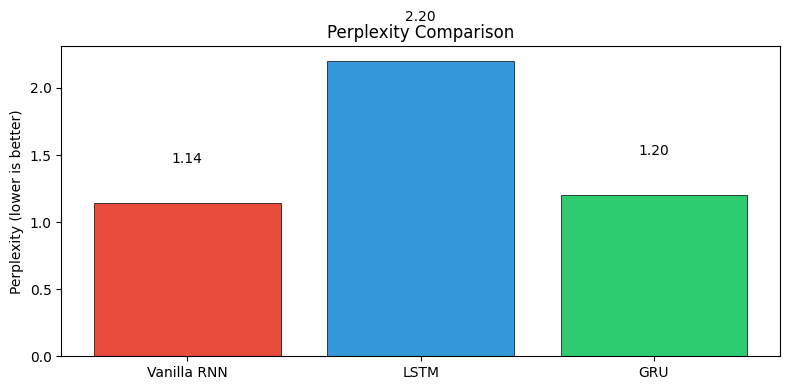

In [20]:
rnn_loss  = rnn_model.evaluate(X, y, verbose=0)[0]
lstm_loss = lstm_model.evaluate(X, y, verbose=0)[0]
gru_loss  = gru_model.evaluate(X, y, verbose=0)[0]

rnn_ppl  = np.exp(rnn_loss)
lstm_ppl = np.exp(lstm_loss)
gru_ppl  = np.exp(gru_loss)

print(f'{"Model":<15} {"Loss":<12} {"Perplexity":<12}')
print('-' * 39)
print(f'{"Vanilla RNN":<15} {rnn_loss:<12.4f} {rnn_ppl:<12.4f}')
print(f'{"LSTM":<15} {lstm_loss:<12.4f} {lstm_ppl:<12.4f}')
print(f'{"GRU":<15} {gru_loss:<12.4f} {gru_ppl:<12.4f}')

# visualize perplexity
plt.figure(figsize=(8, 4))
bars = plt.bar(models, [rnn_ppl, lstm_ppl, gru_ppl], color=colors, edgecolor='black', linewidth=0.5)
for bar, ppl in zip(bars, [rnn_ppl, lstm_ppl, gru_ppl]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{ppl:.2f}', ha='center', fontsize=10)
plt.ylabel('Perplexity (lower is better)')
plt.title('Perplexity Comparison')
plt.tight_layout()
plt.show()

## 11. Embedding Visualization

PCA on the learned embeddings to see if similar words cluster together

Embedding matrix shape: (202, 64)


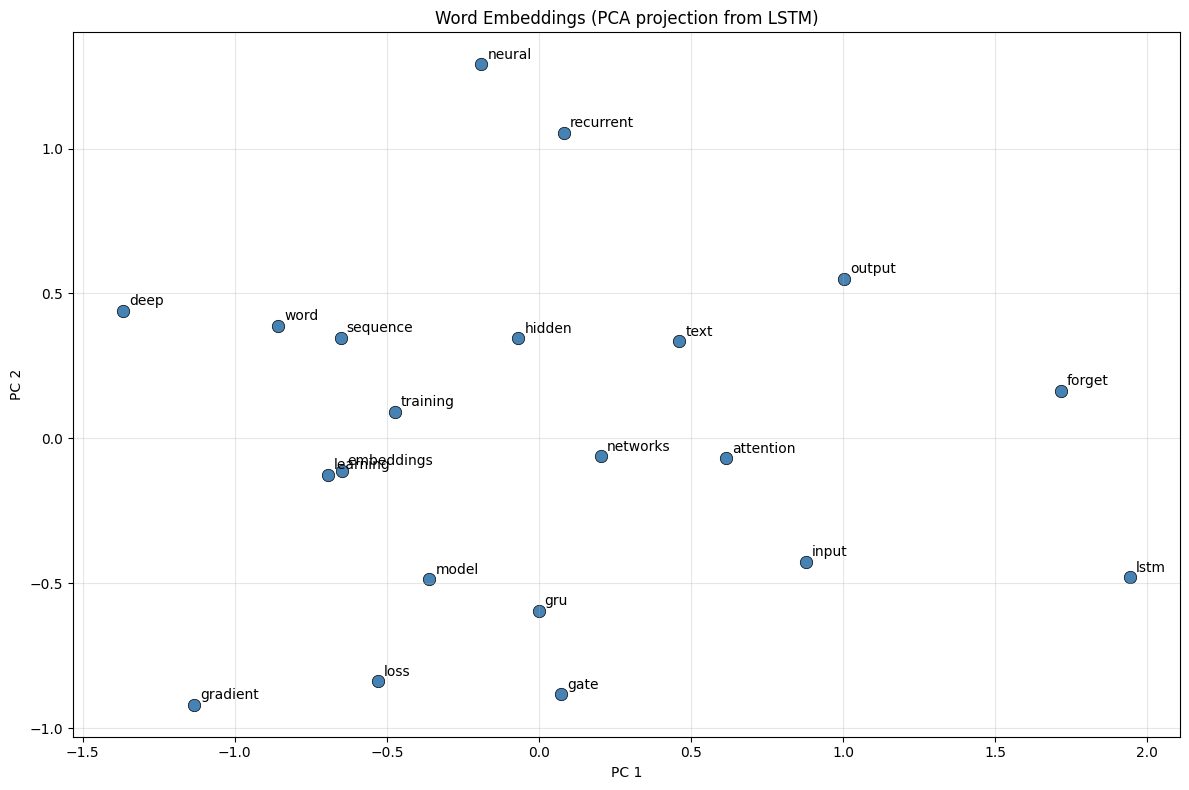

In [21]:
from sklearn.decomposition import PCA

# get embedding weights from the LSTM model
embedding_weights = lstm_model.layers[0].get_weights()[0]
print(f'Embedding matrix shape: {embedding_weights.shape}')  # (vocab_size, embed_dim)

# pick some interesting words to visualize
words_to_plot = ['learning', 'deep', 'neural', 'networks', 'lstm', 'gru',
                 'gradient', 'gate', 'input', 'output', 'forget', 'hidden',
                 'model', 'training', 'loss', 'sequence', 'text', 'word',
                 'embeddings', 'attention', 'recurrent']

# filter to words that exist in our vocabulary
valid_words = [w for w in words_to_plot if w in tokenizer.word_index]
word_vectors = np.array([embedding_weights[tokenizer.word_index[w]] for w in valid_words])

# PCA down to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='steelblue', s=80, edgecolors='black', linewidth=0.5)
for i, word in enumerate(valid_words):
    plt.annotate(word, (coords[i, 0]+0.02, coords[i, 1]+0.02), fontsize=10)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Word Embeddings (PCA projection from LSTM)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Longer Generation

In [22]:
seeds = ['the', 'recurrent neural', 'deep learning models']

for seed in seeds:
    print(f'\n{"="*60}')
    print(f'Seed: "{seed}" | Generating 15 words')
    print(f'{"="*60}')
    print(f'  Vanilla RNN : {generate_text(rnn_model, seed, 15)}')
    print(f'  LSTM        : {generate_text(lstm_model, seed, 15)}')
    print(f'  GRU         : {generate_text(gru_model, seed, 15)}')


Seed: "the" | Generating 15 words


  Vanilla RNN : the forget gate decides what information to discard from the cell state in a recurrent network


  LSTM        : the forget gate decides what information to discard from the cell state state state steps dependencies


  GRU         : the input gate controls which new values update the cell state value value value vector representation

Seed: "recurrent neural" | Generating 15 words


  Vanilla RNN : recurrent neural networks are designed to handle sequential data gate the gate gate determines the next state


  LSTM        : recurrent neural networks are designed to handle sequential data data data dependencies dependencies dependencies dependencies dependencies dependencies


  GRU         : recurrent neural networks are designed to handle sequential data data data data data data classes classes classes

Seed: "deep learning models" | Generating 15 words


  Vanilla RNN : deep learning models require careful tuning of hyperparameters for best results time steps difficult for vanilla rnns amounts


  LSTM        : deep learning models require careful tuning of hyperparameters for best results results dependencies dependencies dependencies dependencies dependencies dependencies


  GRU         : deep learning models require careful tuning of hyperparameters for best results results results results classes results labels steps


## 13. Prediction Confidence

Seed: "deep learning"



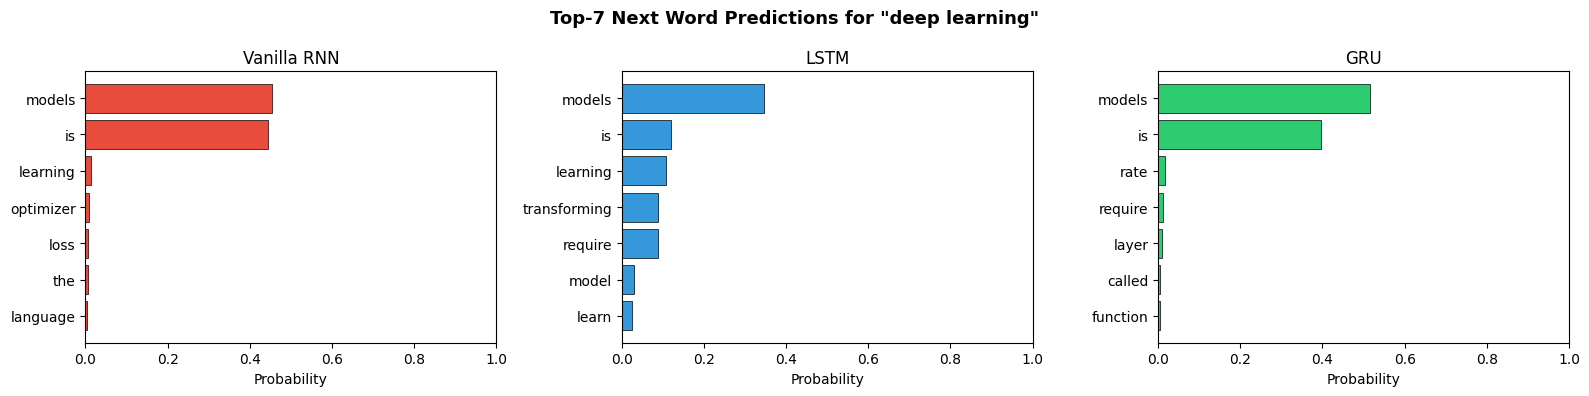

In [23]:
def get_top_predictions(model, seed_text, top_k=5):
    """Get top-k predicted words and their probabilities."""
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    probs = model.predict(token_list, verbose=0)[0]
    
    top_indices = np.argsort(probs)[-top_k:][::-1]
    # reverse lookup
    idx_to_word = {v: k for k, v in tokenizer.word_index.items()}
    
    results = []
    for idx in top_indices:
        word = idx_to_word.get(idx, '<unk>')
        results.append((word, probs[idx]))
    return results

seed = 'deep learning'
print(f'Seed: "{seed}"\n')

model_names = ['Vanilla RNN', 'LSTM', 'GRU']
model_list = [rnn_model, lstm_model, gru_model]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, model in zip(axes, model_names, model_list):
    preds = get_top_predictions(model, seed, top_k=7)
    words = [p[0] for p in preds]
    probs = [p[1] for p in preds]
    
    ax.barh(words[::-1], probs[::-1], color=colors[model_names.index(name)], edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Probability')
    ax.set_title(f'{name}')
    ax.set_xlim(0, 1)

plt.suptitle(f'Top-7 Next Word Predictions for "{seed}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Convergence Speed

In [24]:
threshold = 2.0  # pick a reasonable threshold

histories = {
    'Vanilla RNN': rnn_history.history['loss'],
    'LSTM': lstm_history.history['loss'],
    'GRU': gru_history.history['loss']
}

print(f'Epoch at which loss first drops below {threshold}:')
print('-' * 40)
for name, loss_vals in histories.items():
    reached = False
    for epoch, loss in enumerate(loss_vals, 1):
        if loss < threshold:
            print(f'  {name:<15} : epoch {epoch}')
            reached = True
            break
    if not reached:
        print(f'  {name:<15} : never reached (final loss = {loss_vals[-1]:.4f})')

Epoch at which loss first drops below 2.0:
----------------------------------------
  Vanilla RNN     : epoch 28
  LSTM            : epoch 54
  GRU             : epoch 41


## 15. Summary Table

In [25]:
import pandas as pd

summary_data = {
    'Model': ['Vanilla RNN', 'LSTM', 'GRU'],
    'Parameters': [rnn_params, lstm_params, gru_params],
    'Final Loss': [
        round(rnn_history.history['loss'][-1], 4),
        round(lstm_history.history['loss'][-1], 4),
        round(gru_history.history['loss'][-1], 4)
    ],
    'Final Accuracy': [
        round(rnn_history.history['accuracy'][-1], 4),
        round(lstm_history.history['accuracy'][-1], 4),
        round(gru_history.history['accuracy'][-1], 4)
    ],
    'Perplexity': [
        round(rnn_ppl, 2),
        round(lstm_ppl, 2),
        round(gru_ppl, 2)
    ],
    'Num Gates': [0, 3, 2],
    'Handles Long Dependencies': ['Poor', 'Good', 'Good']
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Model')
print(summary_df.to_string())

             Parameters  Final Loss  Final Accuracy  Perplexity  Num Gates Handles Long Dependencies
Model                                                                                               
Vanilla RNN       63690      0.1727          0.9758        1.14          0                      Poor
LSTM             137802      0.8900          0.8374        2.20          3                      Good
GRU              113482      0.2170          0.9689        1.20          2                      Good


## 16. Observations

- RNN loss plateaus higher than the other two, probably vanishing gradient issue
- LSTM and GRU both converge to much lower loss
- GRU trains a bit faster with fewer params but similar results to LSTM
- RNN generated text is more repetitive, LSTM/GRU outputs are more coherent
- low temperature = boring safe text, high temperature = gibberish, 0.8ish is the sweet spot

## Conclusion

- Vanilla RNN is the simplest but worst at text generation because of vanishing gradients
- LSTM works better because the gates help it remember longer context
- GRU gives similar quality to LSTM but with less parameters and faster training
- overall LSTM/GRU >> vanilla RNN for any sequence task
- nowadays transformers are used instead of all three but this was good to understand the basics